# **Build Custom Object Detector with Detectron2**

<img src="https://dl.fbaipublicfiles.com/detectron2/Detectron2-Logo-Horz.png" width="500">

In [2]:
!pip install 'setuptools<67'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 8.3 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 80.10.2
    Uninstalling setuptools-80.10.2:
      Successfully uninstalled setuptools-80.10.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.


- **Installing Roboflow for Dataset**

In [1]:
!pip install roboflow

- **INSTALLING DTECTRON2**

In [5]:
!python -m pip install pyyaml==5.1
import sys,os,distutils.core

# Note: This is a faster way to install detectron2 in Colab, but it does not include all functionalities (e.g. compiled operators).
# See https://detectron2.readthedocs.io/tutorials/install.html for full installation instructions
# Remove existing directory if you need to re-run the cell
!rm -rf detectron2
!git clone 'https://github.com/facebookresearch/detectron2'

dist = distutils.core.run_setup("./detectron2/setup.py")

!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}
sys.path.insert(0,os.path.abspath('./detectron2'))

  Using cached PyYAML-5.1.tar.gz (274 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Cloning into 'detectron2'...
remote: Enumerating objects: 16057, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 16057 (delta 25), reused 8 (delta 8), pack-reused 16016 (from 3)
Receiving objects: 100% (16057/16057), 6.82 MiB | 11.43 MiB/s, done.
Resolving deltas: 100% (11380/11380), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ...

In [6]:
import torch,detectron2
!nvcc --version

print(f"\nTORCH_VERSION: {'.'.join(torch.__version__.split('.')[:2])}\nCUDA_VERSION: {torch.__version__.split('+')[-1]}\nDETECTRON_VERSION: {detectron2.__version__}")


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0

TORCH_VERSION: 2.11
CUDA_VERSION: cu128
DETECTRON_VERSION: 0.6


- **Imports**

In [8]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os,json,cv2,random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor,DefaultTrainer
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog,DatasetCatalog

- **Let's get Our Dataset**

- **[DATASET LINK](https://universe.roboflow.com/koley/weed-detection-535r5/dataset/3#)**

In [9]:
from google.colab import userdata
api_key = userdata.get("RF")

from roboflow import Roboflow
rf = Roboflow(api_key=api_key)
project = rf.workspace("koley").project("weed-detection-535r5")
version = project.version(3)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to weed-detection-3 in coco-segmentation:: 100%|██████████| 2638/2638 [00:00<00:00, 2812.36it/s]


In [10]:
!pwd

/content


In [11]:
%cd /content/weed-detection-3

/content/weed-detection-3


In [12]:
!cat /content/weed-detection-3/test/_annotations.coco.json

{"info":{"year":"2023","version":"3","description":"Exported from roboflow.com","contributor":"","url":"https://public.roboflow.com/object-detection/undefined","date_created":"2023-11-05T12:49:49+00:00"},"licenses":[{"id":1,"url":"https://creativecommons.org/licenses/by/4.0/","name":"CC BY 4.0"}],"categories":[{"id":0,"name":"weed","supercategory":"none"},{"id":1,"name":"plant","supercategory":"weed"},{"id":2,"name":"weed","supercategory":"weed"}],"images":[{"id":0,"license":1,"file_name":"ijhbnIMG-20230711-WA0005-Copy_jpg.rf.038dc8d6ea479b1b0e3f08c821f5957e.jpg","height":640,"width":640,"date_captured":"2023-11-05T12:49:49+00:00"},{"id":1,"license":1,"file_name":"IMG-20230711-WA0161_jpg.rf.16af814c91aab0ce51411bfe0bd0e03f.jpg","height":640,"width":640,"date_captured":"2023-11-05T12:49:49+00:00"},{"id":2,"license":1,"file_name":"IMG-20230711-WA0211_jpg.rf.03579cd0740ce77fc444b72da89c9b77.jpg","height":640,"width":640,"date_captured":"2023-11-05T12:49:49+00:00"},{"id":3,"license":1,"fil

In [13]:
!pwd

/content/weed-detection-3


- **REGISTER DATASETS**

In [15]:
from detectron2.data.datasets import register_coco_instances

register_coco_instances("exp_train",{},"/content/weed-detection-3/train/_annotations.coco.json","/content/weed-detection-3/train")
register_coco_instances("exp_valid",{},"/content/weed-detection-3/valid/_annotations.coco.json","/content/weed-detection-3/valid")
register_coco_instances("exp_test",{},"/content/weed-detection-3/test/_annotations.coco.json","/content/weed-detection-3/test")

- **Visualize Training Data**

WARNING [09/11 07:02:11 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/11 07:02:11 d2.data.datasets.coco]: Loaded 2301 images in COCO format from /content/weed-detection-3/train/_annotations.coco.json


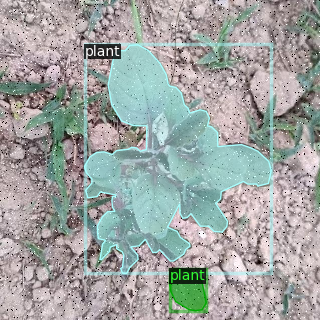

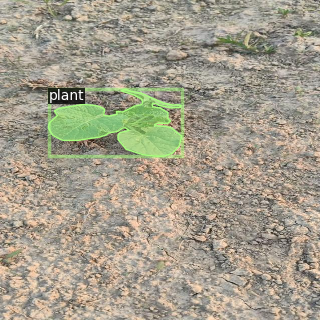

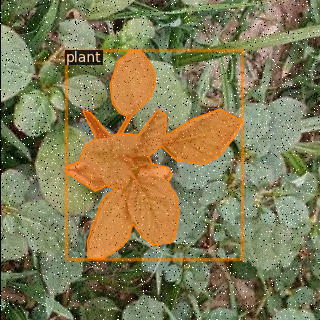

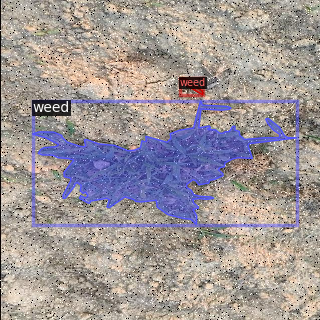

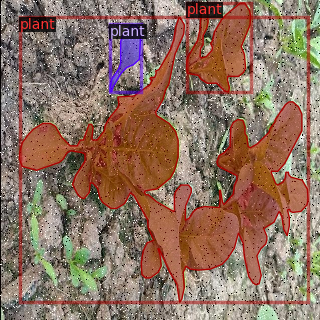

In [16]:
train_metadata = MetadataCatalog.get("exp_train")
dataset_dict = DatasetCatalog.get("exp_train")

import random
from detectron2.utils.visualizer import Visualizer

for d in random.sample(dataset_dict,5):
  im = cv2.imread(d['file_name'])
  vis = Visualizer(im[:,:,::-1],metadata=train_metadata,scale=0.5)
  v = vis.draw_dataset_dict(d)
  cv2_imshow(v.get_image()[:,:,::-1])

- **TRAINING**

In [17]:
cfg = get_cfg()

# Load the Mask R-CNN architecture
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))

# Setup datasets
cfg.DATASETS.TRAIN = ("exp_train",)
cfg.DATASETS.TEST = ("exp_valid",)
cfg.DATALOADER.NUM_WORKERS = 2

# Load pre-trained weights
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")

# Hyperparamater
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.0025
cfg.SOLVER.MAX_ITER = 1000
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3

# Initialize trainer
os.makedirs(cfg.OUTPUT_DIR,exist_ok=True)
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

[09/11 07:19:18 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_f10217.pkl: 178MB [00:00, 232MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
  roi_heads.mask_head.mask_fcn1.{bias, weight}
  roi_heads.mask_head.mask_fcn2.{bias, weight}
  roi_heads.mask_head.mask_fcn3.{bias, weight}
  roi_heads.mask_head.mask_fcn4.{bias, weight}
  roi_heads.mask_head.deconv.{bias, weight}
  roi_heads.mask_head.predictor.{bias, weight}


[09/11 07:19:20 d2.engine.train_loop]: Starting training from iteration 0


torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
W0911 07:19:23.014000 6513 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[09/11 07:19:29 d2.utils.events]:  eta: 0:04:29  iter: 19  total_loss: 1.859  loss_cls: 1.253  loss_box_reg: 0.4723  loss_rpn_cls: 0.03632  loss_rpn_loc: 0.01519    time: 0.2820  last_time: 0.2478  data_time: 0.0145  last_data_time: 0.0048   lr: 4.9952e-05  max_mem: 1740M
[09/11 07:19:39 d2.utils.events]:  eta: 0:04:26  iter: 39  total_loss: 1.101  loss_cls: 0.6259  loss_box_reg: 0.4385  loss_rpn_cls: 0.02961  loss_rpn_loc: 0.01202    time: 0.2831  last_time: 0.2819  data_time: 0.0069  last_data_time: 0.0056   lr: 9.9902e-05  max_mem: 1741M
[09/11 07:19:44 d2.utils.events]:  eta: 0:04:24  iter: 59  total_loss: 1.05  loss_cls: 0.4235  loss_box_reg: 0.5122  loss_rpn_cls: 0.01724  loss_rpn_loc: 0.008698    time: 0.2848  last_time: 0.3217  data_time: 0.0064  last_data_time: 0.0055   lr: 0.00014985  max_mem: 1741M
[09/11 07:19:50 d2.utils.events]:  eta: 0:04:17  iter: 79  total_loss: 0.9197  loss_cls: 0.37  loss_box_reg: 0.4771  loss_rpn_cls: 0.01705  loss_rpn_loc: 0.009128    time: 0.2837 

- **TESTING**

In [19]:
cfg.MODEL.WEIGHTS=os.path.join(cfg.OUTPUT_DIR,'model_final.pth')
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("exp_test",)
predictor = DefaultPredictor(cfg)

[09/11 07:26:35 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./output/model_final.pth ...


- **VISUALIZING RESULT**

In [21]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,4):
  im = cv2.imread(d['file_name'])
  outputs = predictor(im)
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8
  )
  v = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])

Output hidden; open in https://colab.research.google.com to view.

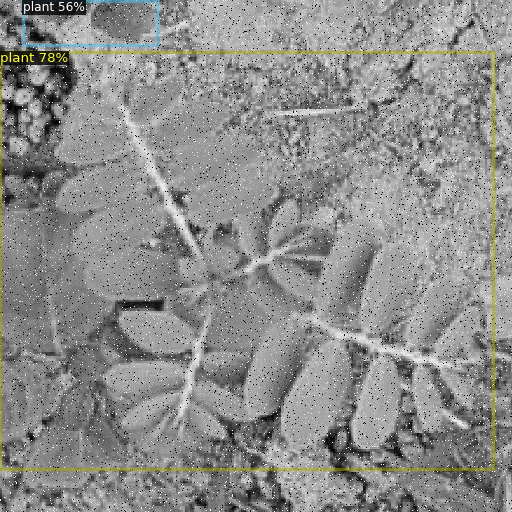

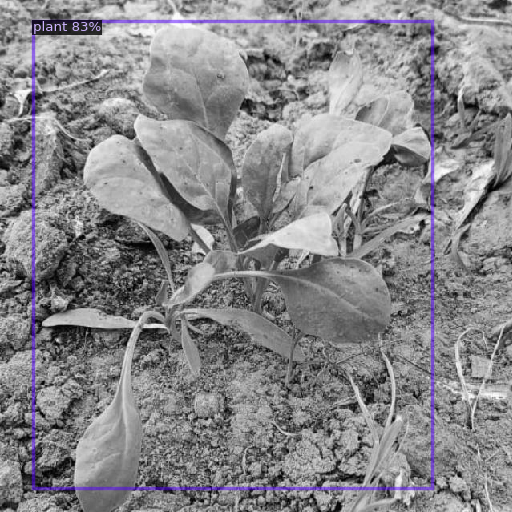

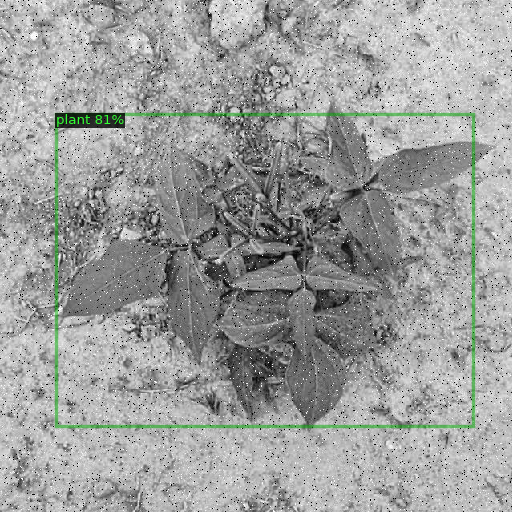

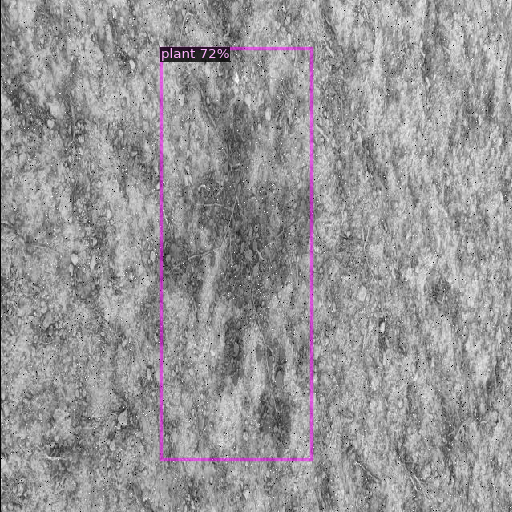

In [23]:
from detectron2.utils.visualizer import ColorMode

for d in random.sample(dataset_dict,4):
  im = cv2.imread(d['file_name'])
  outputs = predictor(im)
  vis = Visualizer(
      im[:,:,::-1],
      metadata = train_metadata,
      scale=0.8,
      instance_mode = ColorMode.IMAGE_BW
  )
  v = vis.draw_instance_predictions(outputs['instances'].to('cpu'))
  cv2_imshow(v.get_image()[:,:,::-1])

- **Evaluation**

In [24]:
from detectron2.evaluation import COCOEvaluator,inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator("exp_test",output_dir="./output")
val_loader = build_detection_test_loader(cfg,"exp_test")
print(inference_on_dataset(predictor.model,val_loader,evaluator))

[09/11 07:31:47 d2.evaluation.coco_evaluation]: Fast COCO eval is not built. Falling back to official COCO eval.
WARNING [09/11 07:31:47 d2.data.datasets.coco]: 
Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.

[09/11 07:31:47 d2.data.datasets.coco]: Loaded 109 images in COCO format from /content/weed-detection-3/test/_annotations.coco.json
[09/11 07:31:47 d2.data.build]: Distribution of instances among all 3 categories:
|  category  | #instances   |  category  | #instances   |  category  | #instances   |
|:----------:|:-------------|:----------:|:-------------|:----------:|:-------------|
|    weed    | 0            |   plant    | 97           |    weed    | 75           |
|            |              |            |              |            |              |
|   total    | 172          |            |              |            |              |
[09/11 07:31:47 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortest

- **Getting the custom config file**

In [25]:
f = open('config.yaml','w')
f.write(cfg.dump())
f.close()